# 🔍 Notebook 01: EDA Cơ Bản Trên BAF Base Dataset

> **Dự án**: Fraud Detection System — BAF Benchmark (NeurIPS 2022)  
> **Mục tiêu**: Phân tích tổng quan dữ liệu `Base.csv`, kiểm tra tỷ lệ imbalanced, phân phối feature, missing values (sentinel values như `-1`), và mối tương quan giữa các đặc trưng với nhãn `fraud_bool`.


In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Config seaborn style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
BASE_PATH = RAW_DATA_DIR / "Base.csv"

print(f"Loading data from: {BASE_PATH}")
df = pd.read_csv(BASE_PATH)
print(f"Shape: {df.shape[0]:,} dòng x {df.shape[1]} cột")


Loading data from: /home/host/fraud_detection/data/raw/Base.csv
Shape: 1,000,000 dòng x 32 cột


## 1. Kiểm tra cấu trúc dữ liệu & Tỷ lệ Class Imbalance


--- Thông tin Data Types ---
int64      18
float64     9
object      5
Name: count, dtype: int64
--- Kiểm tra Class Imbalance (fraud_bool) ---
                Số lượng  Tỷ lệ (%)
Legitimate (0)    988971    98.8971
Fraud (1)          11029     1.1029


/tmp/ipykernel_45707/1783806630.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fraud_bool', ax=ax[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_45707/1783806630.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])


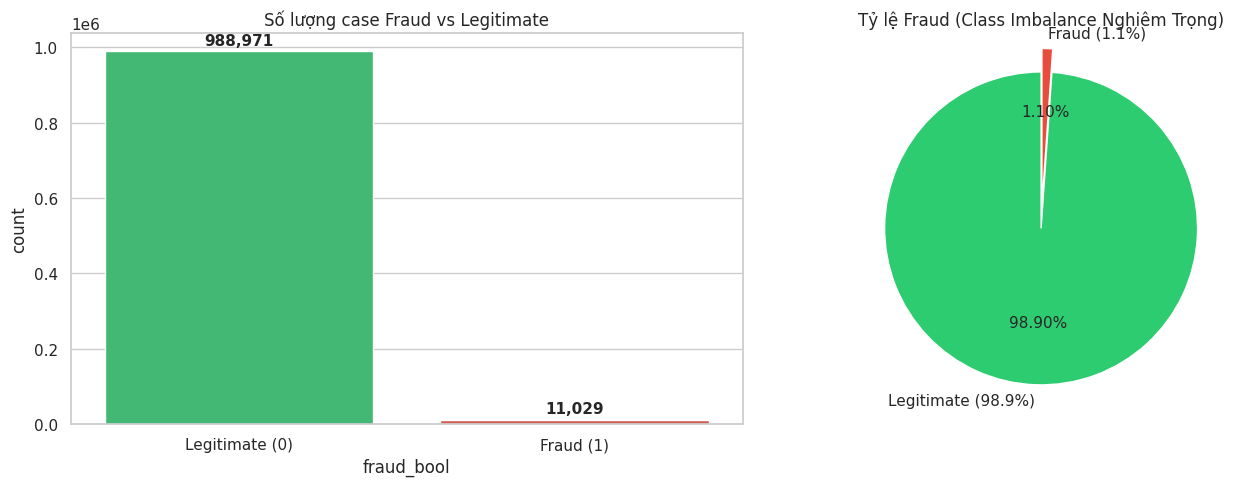

In [4]:
print("--- Thông tin Data Types ---")
print(df.dtypes.value_counts())

print("--- Kiểm tra Class Imbalance (fraud_bool) ---")
fraud_counts = df['fraud_bool'].value_counts()
fraud_rates = df['fraud_bool'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Số lượng': fraud_counts,
    'Tỷ lệ (%)': fraud_rates.round(4)
})
summary_df.index = ['Legitimate (0)', 'Fraud (1)']
print(summary_df)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='fraud_bool', ax=ax[0], palette=['#2ecc71', '#e74c3c'])
ax[0].set_title('Số lượng case Fraud vs Legitimate')
ax[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

ax[1].pie(fraud_counts, labels=['Legitimate (98.9%)', 'Fraud (1.1%)'], 
           autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], explode=(0, 0.15), startangle=90)
ax[1].set_title('Tỷ lệ Fraud (Class Imbalance Nghiêm Trọng)')
plt.tight_layout()
plt.show()


## 2. Kiểm tra Sentinel Values (-1) làm Missing Values
Trong benchmark BAF, các giá trị thiếu (missing data) được mã hóa dưới dạng giá trị sentinel `-1` ở các cột như `prev_address_months_count` và `bank_months_count`.


In [5]:
sentinel_cols = ['prev_address_months_count', 'bank_months_count', 'current_address_months_count']

for col in sentinel_cols:
    if col in df.columns:
        neg_count = (df[col] == -1).sum()
        pct = (neg_count / len(df)) * 100
        print(f"Cột '{col}': {neg_count:,} giá trị = -1 ({pct:.2f}%)")


Cột 'prev_address_months_count': 712,920 giá trị = -1 (71.29%)
Cột 'bank_months_count': 253,635 giá trị = -1 (25.36%)
Cột 'current_address_months_count': 4,254 giá trị = -1 (0.43%)


## 3. Phân phối các Feature Số Quan Trọng (Numerical Features)


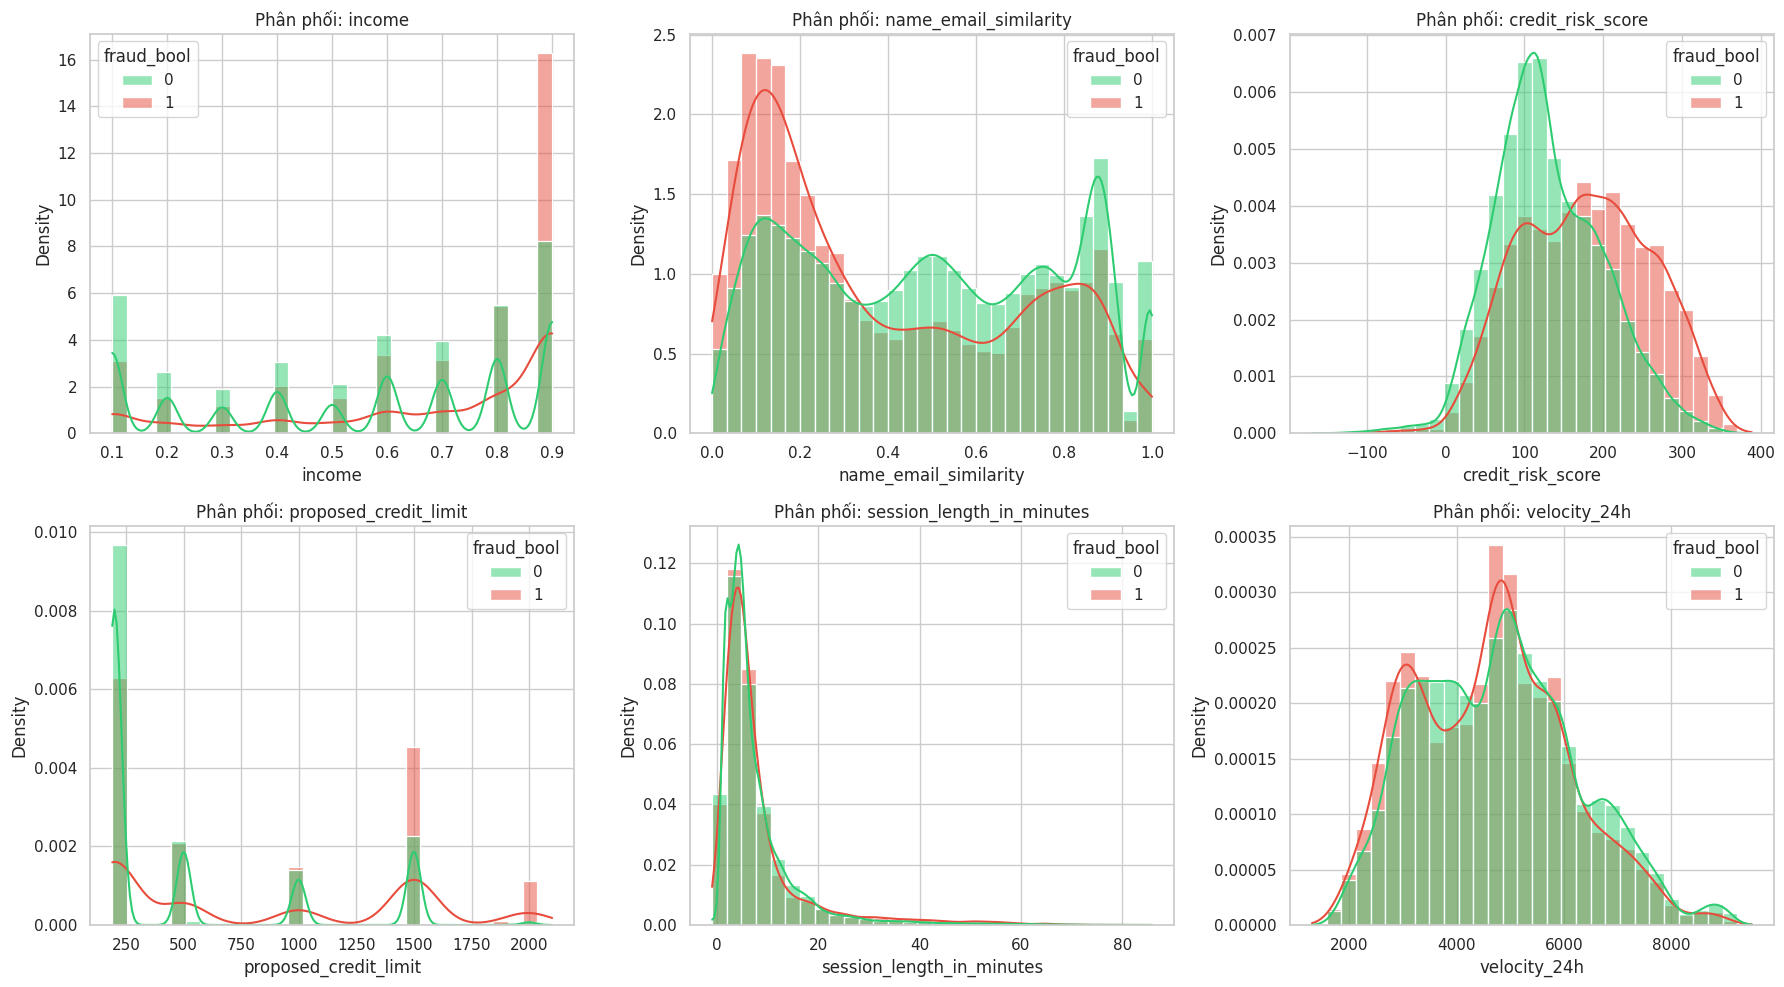

In [6]:
num_cols = ['income', 'name_email_similarity', 'credit_risk_score', 
            'proposed_credit_limit', 'session_length_in_minutes', 'velocity_24h']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='fraud_bool', kde=True, ax=axes[i], 
                 bins=30, palette=['#2ecc71', '#e74c3c'], stat="density", common_norm=False)
    axes[i].set_title(f'Phân phối: {col}')

plt.tight_layout()
plt.show()


## 4. Phân tích Feature Phân Loại (Categorical Features)


/tmp/ipykernel_45707/173942047.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_cat, x=col, y='fraud_rate_%', ax=axes[i], palette='Reds_r')
/tmp/ipykernel_45707/173942047.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_cat, x=col, y='fraud_rate_%', ax=axes[i], palette='Reds_r')
/tmp/ipykernel_45707/173942047.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_cat, x=col, y='fraud_rate_%', ax=axes[i], palette='Reds_r')
/tmp/ipykernel_45707/173942047.py:10: FutureWarning: 

Passing `palette` 

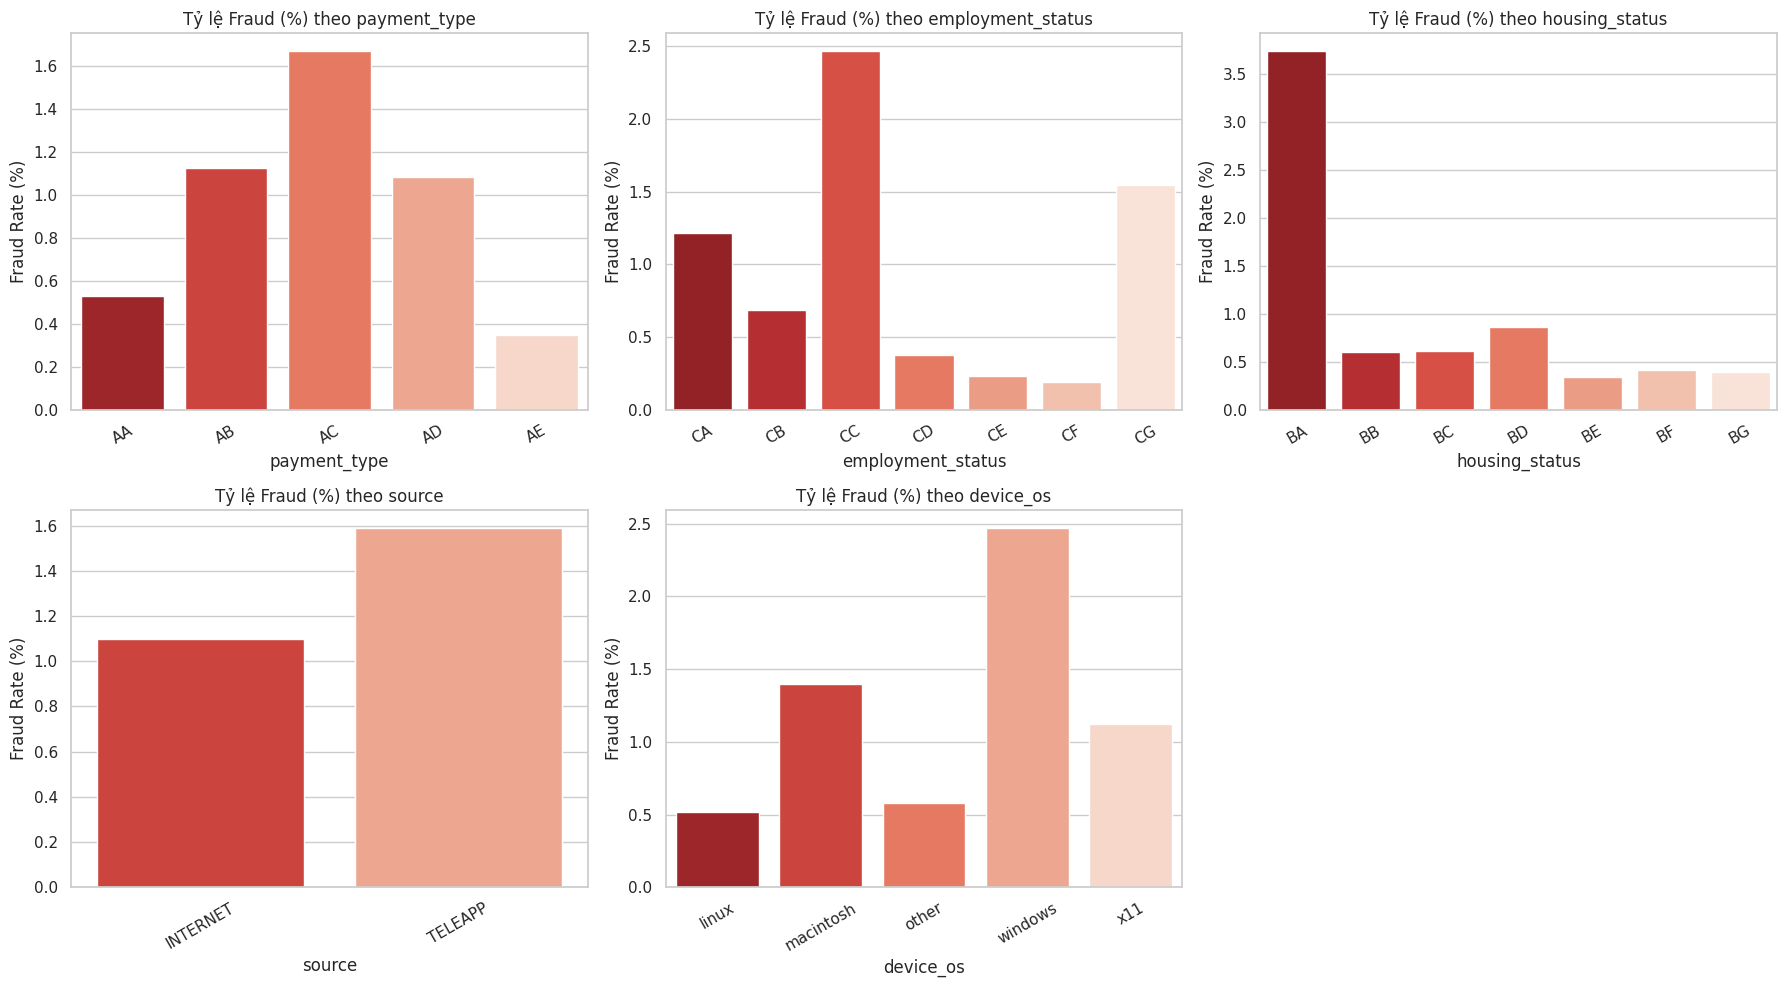

In [7]:
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_by_cat = df.groupby(col)['fraud_bool'].agg(['count', 'mean']).reset_index()
    fraud_by_cat['fraud_rate_%'] = fraud_by_cat['mean'] * 100
    
    sns.barplot(data=fraud_by_cat, x=col, y='fraud_rate_%', ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Tỷ lệ Fraud (%) theo {col}')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

# Clear last unused subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


## 5. Ma Trận Tương Quan (Correlation Matrix với fraud_bool)


--- Top tương quan với fraud_bool ---
fraud_bool                          1.000000
credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
income                              0.045079
device_distinct_emails_8w           0.035704
current_address_months_count        0.033701
email_is_free                       0.027758
foreign_request                     0.016885
month                               0.013250
session_length_in_minutes           0.008999
zip_count_4w                        0.005212
days_since_request                  0.000567
bank_months_count                  -0.003222
velocity_24h                       -0.011183
velocity_4w                        -0.011536
bank_branch_count_8w               -0.011577
phone_mobile_valid                 -0.013180
velocity_6h                        -0.016892
intended_balcon_amount             -0.024524
prev_address_months_count          -0.026031
phone_home_valid 

/tmp/ipykernel_45707/4090069136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_corr.values[1:], y=fraud_corr.index[1:], palette='vlag')


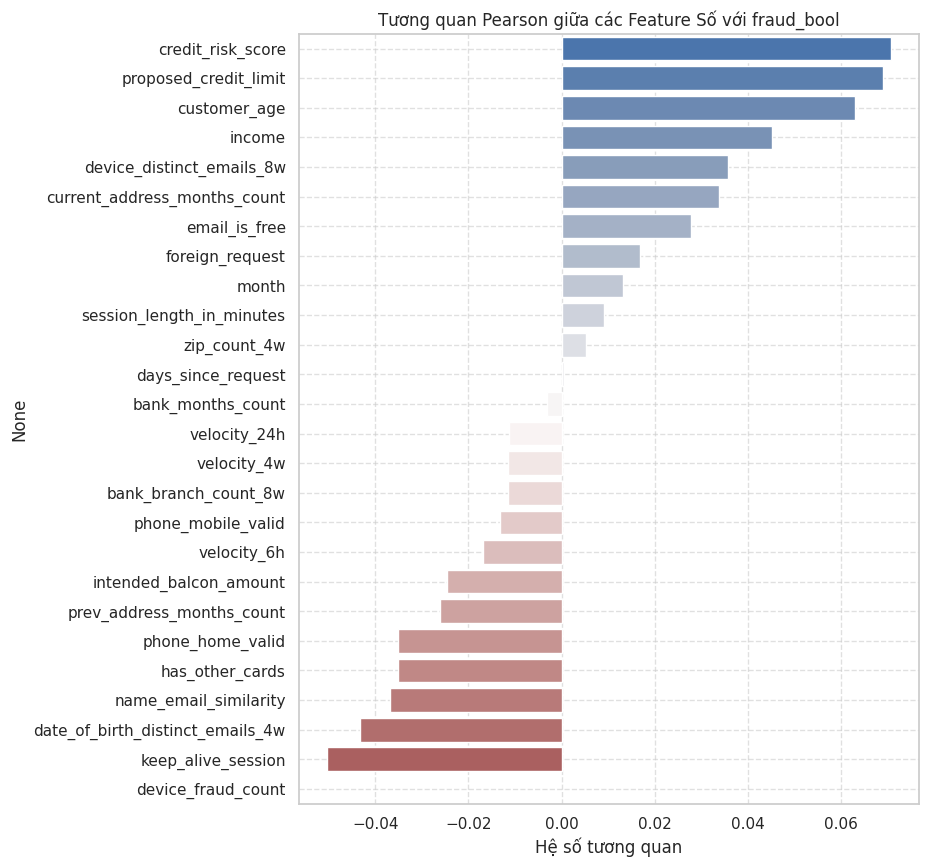

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
fraud_corr = corr['fraud_bool'].sort_values(ascending=False)

print("--- Top tương quan với fraud_bool ---")
print(fraud_corr)

plt.figure(figsize=(8, 10))
sns.barplot(x=fraud_corr.values[1:], y=fraud_corr.index[1:], palette='vlag')
plt.title('Tương quan Pearson giữa các Feature Số với fraud_bool')
plt.xlabel('Hệ số tương quan')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
